In [4]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/12.7 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.7 MB 4.0 MB/s eta 0:00:03
   --------- ------------------------------ 3.1/12.7 MB 4.1 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.7 MB 4.3 MB/s eta 0:00:02
   --------------- ------------------------ 5.0/12.7 MB 4.3 MB/s eta 0:00:02
   -------------------- ------------------- 6.6/12.7 MB 4.6 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.7 MB 4.8 MB/s eta 0:00:01
   ---------------------------- ----------- 9.2/12.7 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.5/12.7 MB 5.1 MB/s eta 0:00:01
   ------------------------------------ --- 11.5/12.7 MB 5.3 MB/s eta 0:00:01
   -------

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
df=pd.read_csv('height-weight.csv', sep=',')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 0, 'Weight')

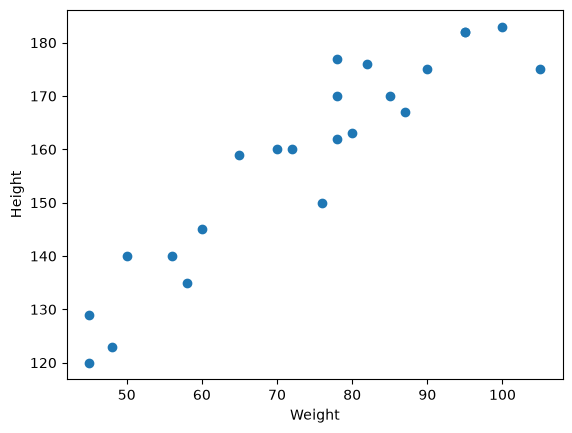

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.ylabel('Height')
plt.xlabel('Weight')

In [4]:
## divide dataset in to dependent and independent features

In [5]:
x= df[['Weight']] ### independent features 
y= df['Height'] ## dependent features

In [6]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [7]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [8]:
# divide into test and train datasets
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.20,random_state= 42)

In [20]:
x_train.shape,y_test.shape

((18, 1), (5,))

In [21]:
x_test.shape

(5, 1)

In [12]:
# standardize the train independent data
from sklearn.preprocessing import StandardScaler

In [13]:
scalar = StandardScaler()

In [22]:
x_train= scalar.fit_transform(x_train)
x_train
x_test=scalar.transform(x_test)
x_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

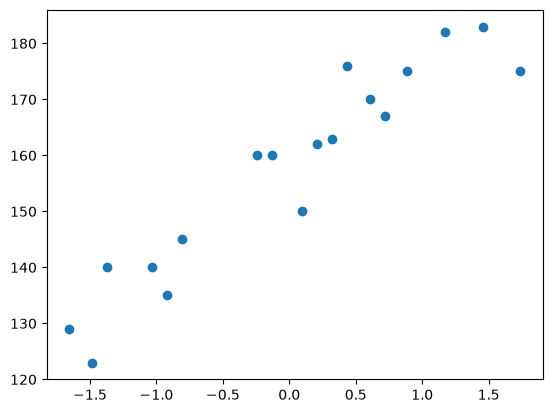

In [23]:
plt.scatter(x_train,y_train)

In [ ]:
## now train simple linear regression model 

In [24]:
from sklearn.linear_model import LinearRegression

In [28]:
linear = LinearRegression()

In [29]:
linear.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.24]


In [32]:
print("cofficient of linear regression model",linear.coef_)
print("intercept of linear regression model", linear.intercept_)

cofficient of linear regression model [17.03440872]
intercept of linear regression model 157.5


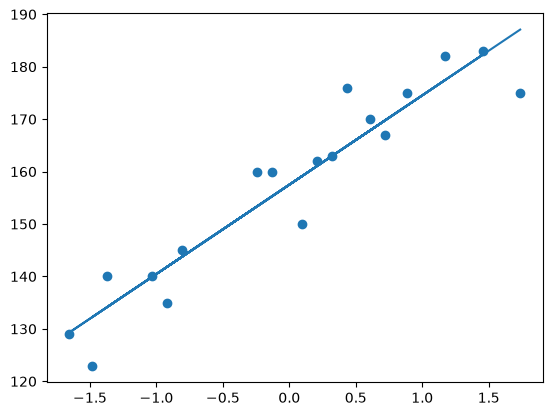

In [35]:
# now plot regression model
plt.scatter(x_train, y_train)
plt.plot(x_train, linear.predict(x_train))

Prediction of train data

y_predict = intercept + coef_(x_train)
y_predict = 157.5 + 17.03(x_train)

Prediction of test data

y_predict_test = intercept + coef_(x_test)
y_predict_test = 157.5 + 17.03(x_test)

In [38]:
y_pred_test = linear.predict(x_test)
y_pred_test, y_test


(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

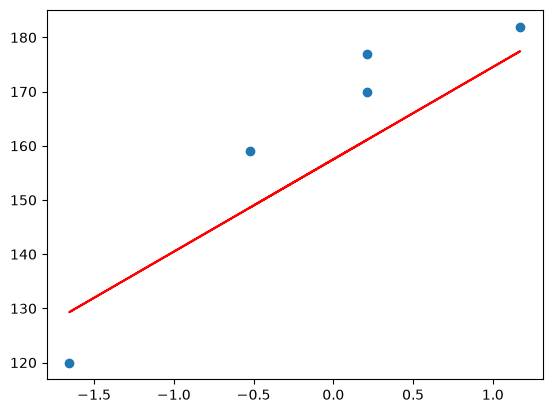

In [39]:
plt.scatter(x_test, y_test)
plt.plot(x_test, linear.predict(x_test), 'r')


Performance metrics

MSE, MAE, RMSE

RSquared and adjusted r squared


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
mse= mean_squared_error(y_test, y_pred_test)
mae= mean_absolute_error(y_test, y_pred_test)
rmse= np.sqrt(mse)
print("mean squared error,", mse)
print("mean squared error,", mae)
print("mean squared error,", rmse)

mean squared error, 109.77592599051664
mean squared error, 9.822657814519232
mean squared error, 10.477400726827081


In [46]:
r2score= r2_score(y_test, y_pred_test)
r2score

0.776986986042344

In [48]:
#adjusted r squared

adjustedr2= 1-(1-r2score)* (len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
adjustedr2

0.7026493147231252

In [49]:
## To the height prediction for 80kg weight 
scaled_weight=scalar.transform([[80]])
scaled_weight

c:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [50]:
print(linear.predict([scaled_weight[0]]))

[163.01076266]


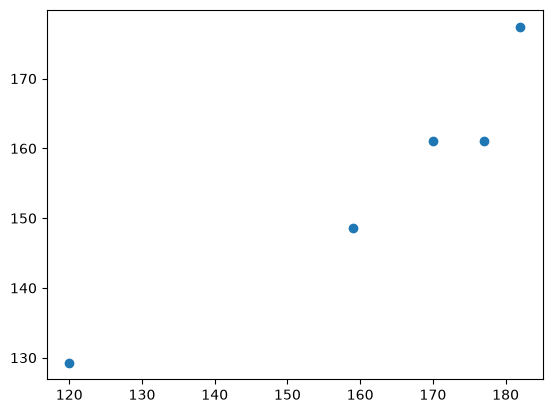

In [51]:
#assumption 
## plot a scatter plot for the prediction
plt.scatter(y_test, y_pred_test)

In [54]:
 residual= y_test- y_pred_test

C:\Users\ayush\AppData\Local\Temp\ipykernel_16684\409225237.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test- y_pred_test,kde= True)


<Axes: xlabel='Height', ylabel='Density'>

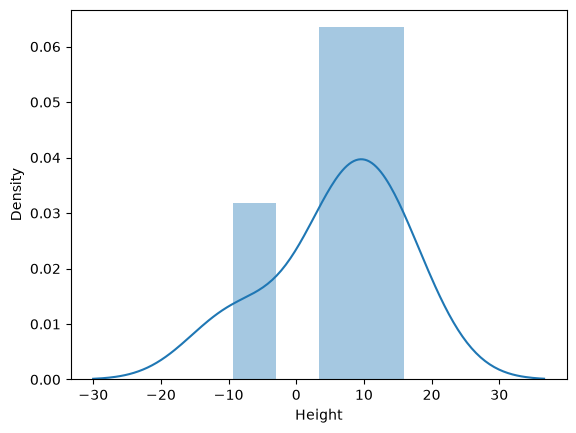

In [57]:
import seaborn as sns
sns.distplot(y_test- y_pred_test,kde= True)

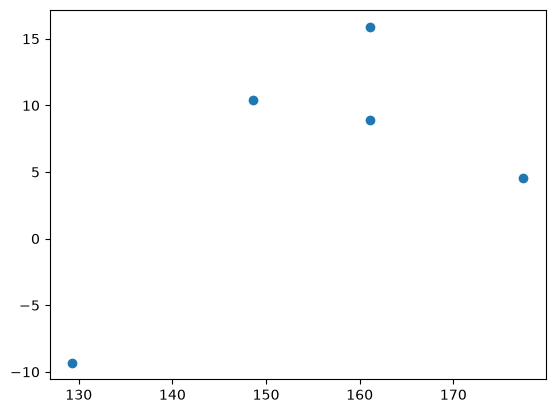

In [58]:
plt.scatter(y_pred_test, residual)